# Computer Vision Project

## Importing Modules

In [71]:
import matplotlib.pyplot as plt
import random
from sklearn.metrics import f1_score, accuracy_score

import tensorflow as tf
import keras

datasets = keras.datasets
layers = keras.layers
models = keras.models

print("imported")

imported


## Importing Data

In [72]:
# Path to image folder
images_dir = "images"

# Common settings
img_size = (128, 128)
batch_size = 32
seed = 123

# Load training and validation datasets from the same folder using a split
dataset_training = tf.keras.utils.image_dataset_from_directory(
    images_dir + "/training",
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

dataset_validation = tf.keras.utils.image_dataset_from_directory(
    images_dir + "/training",
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

# Keep test dataset separate for final evaluation
dataset_test = tf.keras.utils.image_dataset_from_directory(
    images_dir + "/testing",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

Found 2392 files belonging to 2 classes.
Using 1914 files for training.
Found 2392 files belonging to 2 classes.
Using 478 files for validation.
Found 597 files belonging to 2 classes.


## Exploring the Dataset

In [73]:
print(dataset_training.class_names)

['flip', 'notflip']


Printing the classes for imagens on the Dataset.

### Image Exemples

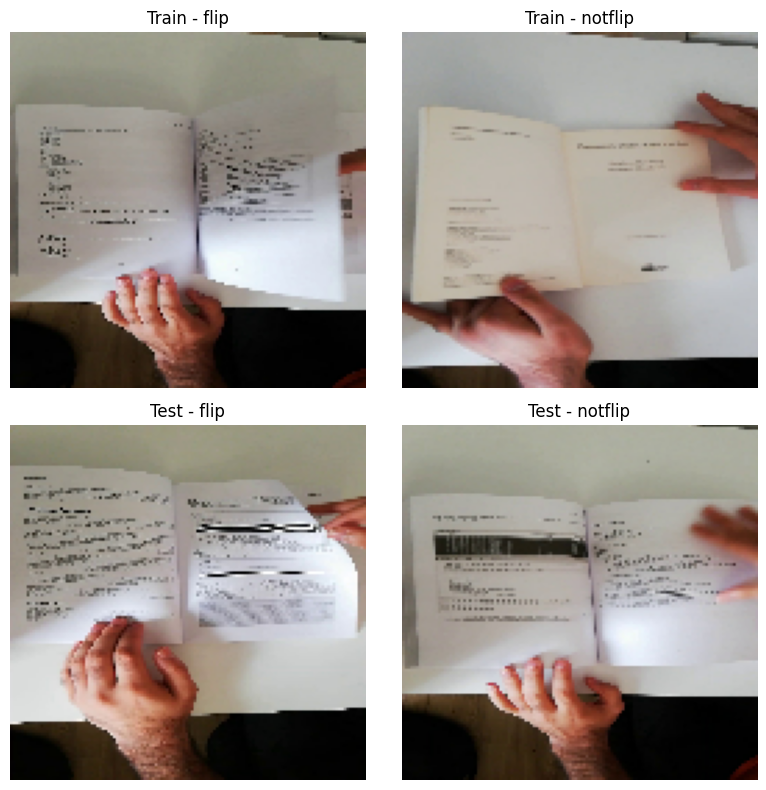

In [74]:
# Show one example image per class for both training and test datasets

class_names = dataset_training.class_names
n_classes_to_show = min(2, len(class_names))  

def get_examples_by_class(ds, n_classes=2, max_batches=20):
    examples = {i: None for i in range(n_classes)}
    found = 0

    for images, labels in ds.take(max_batches):
        labels_np = labels.numpy()
        for i in range(images.shape[0]):
            cls = int(labels_np[i])
            if cls < n_classes and examples[cls] is None:
                examples[cls] = images[i].numpy().astype("uint8")
                found += 1
                if found == n_classes:
                    return examples
    return examples

train_examples = get_examples_by_class(dataset_training, n_classes=n_classes_to_show)
test_examples = get_examples_by_class(dataset_test, n_classes=n_classes_to_show)

fig, axes = plt.subplots(2, n_classes_to_show, figsize=(4 * n_classes_to_show, 8))

for cls_idx in range(n_classes_to_show):
    
    # Training row
    ax = axes[0, cls_idx] if n_classes_to_show > 1 else axes[0]
    img = train_examples[cls_idx]
    if img is not None:
        ax.imshow(img)
    ax.set_title(f"Train - {class_names[cls_idx]}")
    ax.axis("off")

    # Test row
    ax = axes[1, cls_idx] if n_classes_to_show > 1 else axes[1]
    img = test_examples[cls_idx]
    if img is not None:
        ax.imshow(img)
    ax.set_title(f"Test - {class_names[cls_idx]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

This shows exemples of images on both the Training and Test datasets and their respective classes. These images where resized, so that is why the images can be a bit pixelated.

### Class Distribution

In [75]:
def counting_number_records(ds):
    values = {}

    for images, labels in ds:
        labels = labels.numpy()  

        for label in labels:
            label = int(label)
            if label not in values:
                values[label] = 0
            values[label] += 1
    
    return values

In [76]:
counting_training = counting_number_records(dataset_training) 

counting_test = counting_number_records(dataset_test) 

class_names = dataset_training.class_names

In [77]:
print('The Training Dataset:')

for label, count in counting_training.items():
    print(f'{class_names[label]} has {count} records')

The Training Dataset:
flip has 928 records
notflip has 986 records


In [78]:
print('The Test Dataset:')

for label, count in counting_test.items():
    print(f'{class_names[label]} has {count} records')

The Test Dataset:
flip has 290 records
notflip has 307 records


Text(0.5, 1.0, 'Class Distribution')

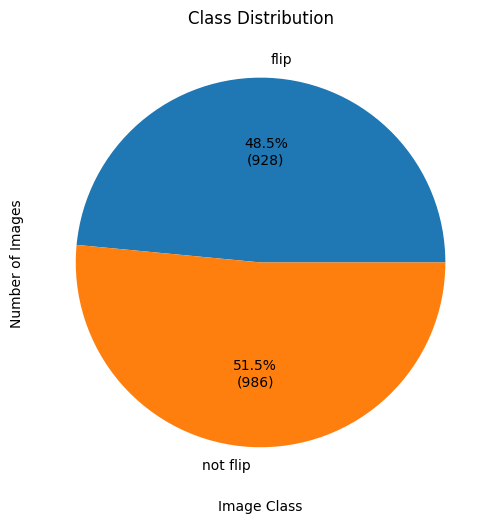

In [79]:
labels = ['flip','not flip']

fig = plt.subplots(1, 1, figsize=(6, 6))

def make_autopct(values):
    def my_autopct(pct):
        absolute = int(round(pct / 100. * sum(values)))
        return f'{pct:.1f}%\n({absolute})'
    return my_autopct

plt.pie(counting_training.values(), labels=labels, autopct=make_autopct(counting_training.values()))

plt.xlabel('Image Class')
plt.ylabel('Number of Images')
plt.title('Class Distribution')

This Pie graph shows that the class distribution is fairly well balanced, meaning that we won't have to worry much about class weights and samplings.

## NeuralNets

### Data Processing

In [80]:
rescaling_layer = tf.keras.layers.Rescaling(1./255)

dataset_training = dataset_training.map(lambda x, y: (rescaling_layer(x), y))
dataset_validation = dataset_validation.map(lambda x, y: (rescaling_layer(x), y))
dataset_test = dataset_test.map(lambda x, y: (rescaling_layer(x), y))

In [81]:
dataset_training = dataset_training.cache()
dataset_validation = dataset_validation.cache()
dataset_test = dataset_test.cache()

### NeuralNet Implementation

In [82]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
])

#### NeuralNet Definition

In [83]:
size = 128
random.seed(0)
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(size, size, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))
model.add(layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))
model.add(layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)))
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.25))
model.add(layers.Dense(1))

In [84]:
lr = 0.001
model.compile(optimizer=tf.keras.optimizers.Adam(lr),
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])

#### Training

In [85]:
epochs=30
history = model.fit(
  dataset_training,
  validation_data=dataset_validation,
  epochs=epochs,
  verbose=1
)

Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 396ms/step - accuracy: 0.4916 - loss: 1.7933 - val_accuracy: 0.4895 - val_loss: 1.2733
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 23s 386ms/step - accuracy: 0.5266 - loss: 1.1433 - val_accuracy: 0.5502 - val_loss: 1.0703
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 349ms/step - accuracy: 0.5935 - loss: 0.9450 - val_accuracy: 0.6841 - val_loss: 0.8507
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 333ms/step - accuracy: 0.8051 - loss: 0.6828 - val_accuracy: 0.8577 - val_loss: 0.5667
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 309ms/step - accuracy: 0.9091 - loss: 0.4520 - val_accuracy: 0.9100 - val_loss: 0.4076
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 330ms/step - accuracy: 0.9545 - loss: 0.3159 - val_accuracy: 0.9498 - val_loss: 0.3054
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 16s 263ms/step - accuracy: 0.9718 - loss: 0.2400 - val_accuracy: 0.9665 - val_loss: 0.2321
Epoch 8/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 16s 266ms/step - accuracy: 0.9786 - loss: 0.1984 - val_accu

In [89]:
model_path = "monreader_model.keras"
model.save(model_path)
print(f"Model saved as {model_path}")

Model saved as monreader_model.keras


### Evaluation

In [87]:
# Get predictions on test dataset
y_true = []
y_pred = []

for images, labels in dataset_test:
    predictions = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend((predictions > 0.5).astype(int).flatten())

# Calculate metrics
test_accuracy = accuracy_score(y_true, y_pred)
test_f1 = f1_score(y_true, y_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 564ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
Test Accuracy: 0.9933
Test F1 Score: 0.9935


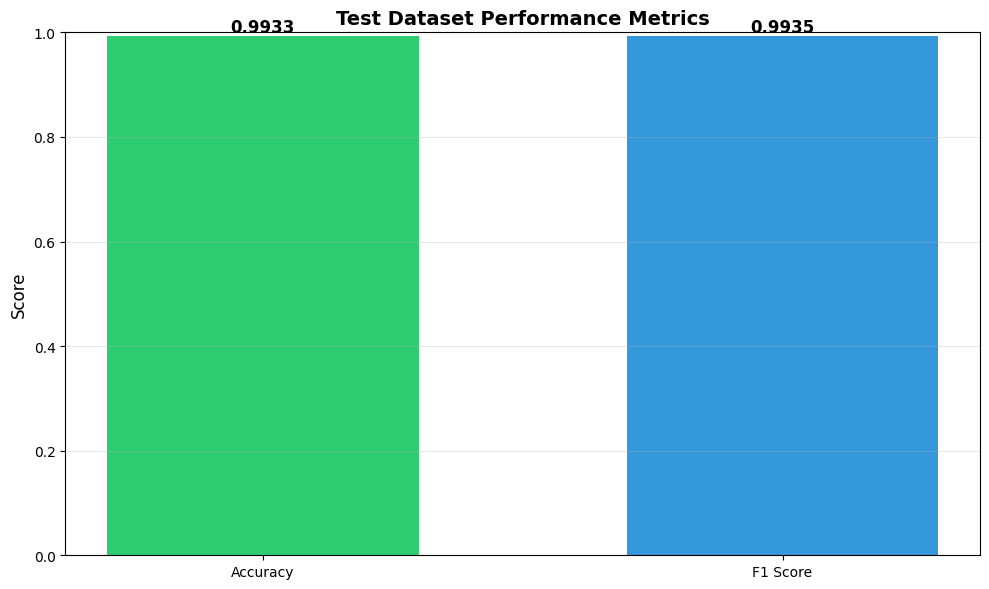


Test Set Performance Summary:
  Accuracy: 0.9933
  F1 Score: 0.9935


In [88]:
plt.figure(figsize=(10, 6))

metrics = ['Accuracy', 'F1 Score']
scores = [test_accuracy, test_f1]

bars = plt.bar(metrics, scores, color=['#2ecc71', '#3498db'], width=0.6)

# Add value labels on bars
for bar, score in zip(bars, scores):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{score:.4f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylim(0, 1)
plt.ylabel('Score', fontsize=12)
plt.title('Test Dataset Performance Metrics', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTest Set Performance Summary:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  F1 Score: {test_f1:.4f}")